In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

## Предобработка данных

In [2]:
df_real_cnc = pd.read_csv('json_data.csv',sep=',')

In [3]:
df_real_cnc

,id,core_uptime_current,channel_uptime_total,program_completion_percent,program_name,channel_status,channel_mode,error_message,source,created_at
0,1,256:45:32,317:48:05,48,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T22:33:34.000Z"""
1,2,128:04:21,253:54:54,83,/NC/examples/04_06.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:33:34.000Z"""
2,3,128:14:21,254:01:12,0,NaN,Готов,Авто,NaN,get/3,"""2025-10-11T22:43:34.000Z"""
3,4,256:55:32,317:58:04,60,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T22:43:34.000Z"""
4,5,128:24:20,254:06:41,92,/NC/examples/04_25.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:53:34.000Z"""
...,...,...,...,...,...,...,...,...,...,...
665,666,314:33:30,375:31:14,53,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-14T08:21:31.000Z"""
666,667,314:54:53,375:52:38,76,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-14T08:42:54.000Z"""
667,668,186:13:41,283:41:09,18,/NC/examples/08_01.nc,Работа,Авто,NaN,get/3,"""2025-10-14T08:42:54.000Z"""
668,669,186:33:45,283:52:09,70,/NC/examples/10_03.nc,Работа,Авто,NaN,get/3,"""2025-10-14T09:02:58.000Z"""


In [4]:
# Функция для перевода времени в часы
def str_to_dec_h(s, digits=2):
    parts = s.split(':')              
    h, m, sec = map(int, parts)
 
    time_in_h =  h + m/60 + sec/3600
    return round(time_in_h, digits)

df_real_cnc['core_uptime_current']  = df_real_cnc['core_uptime_current'].apply(str_to_dec_h)
df_real_cnc['channel_uptime_total'] = df_real_cnc['channel_uptime_total'].apply(str_to_dec_h)


In [5]:
df_real_cnc.sample(5)

,id,core_uptime_current,channel_uptime_total,program_completion_percent,program_name,channel_status,channel_mode,error_message,source,created_at
503,504,299.01,359.99,30,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-13T16:48:33.000Z"""
282,283,151.89,266.11,84,/NC/examples/10_04.nc,Работа,Авто,NaN,get/3,"""2025-10-12T22:22:22.000Z"""
550,551,304.94,365.92,20,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-13T22:44:42.000Z"""
232,233,276.41,337.42,42,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-12T18:12:22.000Z"""
126,127,138.57,259.31,90,/NC/examples/04_10.nc,Работа,Авто,NaN,get/3,"""2025-10-12T09:03:34.000Z"""


In [6]:
df_real_cnc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          670 non-null    int64  
 1   core_uptime_current         670 non-null    float64
 2   channel_uptime_total        670 non-null    float64
 3   program_completion_percent  670 non-null    int64  
 4   program_name                582 non-null    object 
 5   channel_status              670 non-null    object 
 6   channel_mode                670 non-null    object 
 7   error_message               36 non-null     object 
 8   source                      670 non-null    object 
 9   created_at                  670 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 52.5+ KB


In [7]:
df_real_cnc.describe()

,id,core_uptime_current,channel_uptime_total,program_completion_percent
count,670.000000,670.000000,670.000000,670.000000
mean,335.500000,220.939552,307.414060,50.311940
std,193.556624,66.574272,41.150582,34.231294
min,1.000000,128.070000,253.910000,0.000000
25%,168.250000,156.262500,268.392500,18.000000
50%,335.500000,221.660000,300.835000,57.000000
75%,502.750000,284.867500,345.867500,81.000000
max,670.000000,315.250000,376.210000,100.000000


## Посчитайте, какой статус первого канала в ЧПУ был большее количество времени?

In [8]:
df_real_cnc = df_real_cnc.sort_values(['source', 'created_at'])

# Считаем разницу времени по статусу и источнику
df_real_cnc['uptime_diff'] = df_real_cnc.groupby(['source', 'channel_status'])['channel_uptime_total'].diff()

# Заменяем NaN 
df_real_cnc['uptime_diff'] = df_real_cnc['uptime_diff'].fillna(0)

# Исключаем отрицательные значения, чтобы не считать сбросы, как отрицательное время
df_real_cnc = df_real_cnc[df_real_cnc['uptime_diff'] >= 0]

df_real_cnc

,id,core_uptime_current,channel_uptime_total,program_completion_percent,program_name,channel_status,channel_mode,error_message,source,created_at,uptime_diff
1,2,128.07,253.91,83,/NC/examples/04_06.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:33:34.000Z""",0.00
2,3,128.24,254.02,0,NaN,Готов,Авто,NaN,get/3,"""2025-10-11T22:43:34.000Z""",0.00
4,5,128.41,254.11,92,/NC/examples/04_25.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:53:34.000Z""",0.20
6,7,128.57,254.21,78,/NC/examples/05_07.nc,Работа,Авто,NaN,get/3,"""2025-10-11T23:03:34.000Z""",0.10
8,9,128.74,254.30,80,/NC/examples/05_17.nc,Работа,Авто,NaN,get/3,"""2025-10-11T23:13:34.000Z""",0.09
...,...,...,...,...,...,...,...,...,...,...,...
661,662,314.22,375.19,32,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-14T08:01:30.000Z""",0.17
662,663,314.39,375.35,43,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-14T08:11:30.000Z""",0.16
665,666,314.56,375.52,53,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-14T08:21:31.000Z""",0.17
666,667,314.91,375.88,76,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-14T08:42:54.000Z""",0.36


In [9]:
# стенд набора тестовых программ
df_cnc3 =  df_real_cnc.query('source == "get/3"')
df_cnc3.head()

,id,core_uptime_current,channel_uptime_total,program_completion_percent,program_name,channel_status,channel_mode,error_message,source,created_at,uptime_diff
1,2,128.07,253.91,83,/NC/examples/04_06.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:33:34.000Z""",0.00
2,3,128.24,254.02,0,NaN,Готов,Авто,NaN,get/3,"""2025-10-11T22:43:34.000Z""",0.00
4,5,128.41,254.11,92,/NC/examples/04_25.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:53:34.000Z""",0.20
6,7,128.57,254.21,78,/NC/examples/05_07.nc,Работа,Авто,NaN,get/3,"""2025-10-11T23:03:34.000Z""",0.10
8,9,128.74,254.30,80,/NC/examples/05_17.nc,Работа,Авто,NaN,get/3,"""2025-10-11T23:13:34.000Z""",0.09


In [10]:
# стенд гравировального станка
df_cnc5 =  df_real_cnc.query('source == "get/5"')
df_cnc5.head()

,id,core_uptime_current,channel_uptime_total,program_completion_percent,program_name,channel_status,channel_mode,error_message,source,created_at,uptime_diff
0,1,256.76,317.80,48,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T22:33:34.000Z""",0.00
3,4,256.93,317.97,60,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T22:43:34.000Z""",0.17
5,6,257.09,318.13,70,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T22:53:34.000Z""",0.16
7,8,257.26,318.30,81,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T23:03:34.000Z""",0.17
9,10,257.43,318.47,91,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T23:13:34.000Z""",0.17


In [11]:
# Рассчитываем время работы каждого статуса для стенда с набором тестовых программ
status_time_cnc3 = df_cnc3.groupby('channel_status', as_index=False) \
    .agg({'uptime_diff':'sum'}) \
    .sort_values('uptime_diff', ascending=False).reset_index(drop=True) 

status_time_cnc3 = status_time_cnc3.rename(columns={'uptime_diff': 'total_time_hours'})

status_time_cnc3

,channel_status,total_time_hours
0,Работа,29.96
1,Готов,29.52
2,Ошибка,27.65
3,Останов,27.22
4,Загрузка,22.61
5,Готов к запуску,17.16


In [12]:
# Рассчитываем время работы каждого статуса для стенда гравировального станка
status_time_cnc5 = df_cnc5.groupby('channel_status', as_index=False) \
    .agg({'uptime_diff':'sum'}) \
    .sort_values('uptime_diff', ascending=False).reset_index(drop=True) 

status_time_cnc5 = status_time_cnc5.rename(columns={'uptime_diff': 'total_time_hours'})


status_time_cnc5

,channel_status,total_time_hours
0,Работа,58.41


#### За период сбора данных стенд гравировального станка работал бесперебойно. Скорее всего не удалось отследить остальные статусы, потому что данные парсились каждые 10 минут и таких критических ошибок или остановок не было

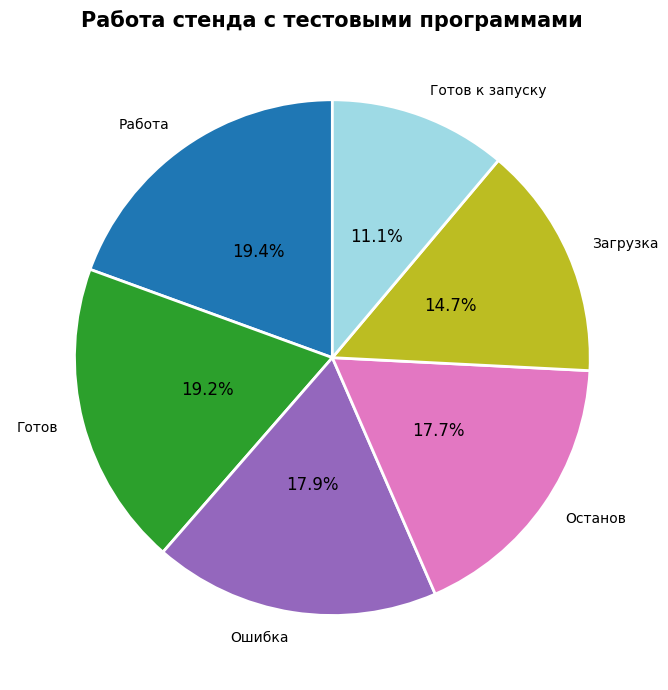

In [13]:
# Визуализация для для стенда с набором тестовых программ
sizes = status_time_cnc3['total_time_hours']
labels = status_time_cnc3['channel_status']

colors = plt.cm.tab20(np.linspace(0, 1, len(sizes)))

plt.figure(figsize=(8, 7))


patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.5,  
    labeldistance=1.1, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)


for autotext in autotexts:
    autotext.set_horizontalalignment('center')
    autotext.set_verticalalignment('center')
    autotext.set (fontsize=12)
    autotext.set_color('black')

plt.title('Работа стенда с тестовыми программами', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Какая программа была запущена дольше всего?

In [14]:
# Стенд с набором тестовых программ
df_cnc3.head()

,id,core_uptime_current,channel_uptime_total,program_completion_percent,program_name,channel_status,channel_mode,error_message,source,created_at,uptime_diff
1,2,128.07,253.91,83,/NC/examples/04_06.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:33:34.000Z""",0.00
2,3,128.24,254.02,0,NaN,Готов,Авто,NaN,get/3,"""2025-10-11T22:43:34.000Z""",0.00
4,5,128.41,254.11,92,/NC/examples/04_25.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:53:34.000Z""",0.20
6,7,128.57,254.21,78,/NC/examples/05_07.nc,Работа,Авто,NaN,get/3,"""2025-10-11T23:03:34.000Z""",0.10
8,9,128.74,254.30,80,/NC/examples/05_17.nc,Работа,Авто,NaN,get/3,"""2025-10-11T23:13:34.000Z""",0.09


In [15]:
top_program_cnc3 = df_cnc3.sort_values(['source', 'created_at'])

top_program_cnc3['core_uptime_diff'] = top_program_cnc3.groupby(['source', 'program_name'])['core_uptime_current'].diff()
top_program_cnc3['core_uptime_diff'] = top_program_cnc3['core_uptime_diff'].fillna(0)
top_program_cnc3 = top_program_cnc3[top_program_cnc3['core_uptime_diff'] >= 0]

program_time_df = top_program_cnc3.groupby('program_name', as_index=False)['core_uptime_diff'].sum()
program_time_df = program_time_df.rename(columns={'core_uptime_diff': 'total_time_hours'})
program_time_df = program_time_df.sort_values('total_time_hours', ascending=False).reset_index(drop=True)
program_time_df.head()

,program_name,total_time_hours
0,/NC/examples/08_01.nc,55.49
1,/NC/examples/10_14.nc,53.80
2,/NC/examples/04_06.nc,53.80
3,/NC/examples/08_04.nc,53.80
4,/NC/examples/04_03.nc,53.80


In [16]:
print(f'Всего программ: {program_time_df.program_name.nunique()}')

Всего программ: 82


/var/folders/_q/y78js8613z37pq4ldhx06pc00000gn/T/ipykernel_4142/2583376117.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_programs, x='total_time_hours', y='program_name', palette='rocket')


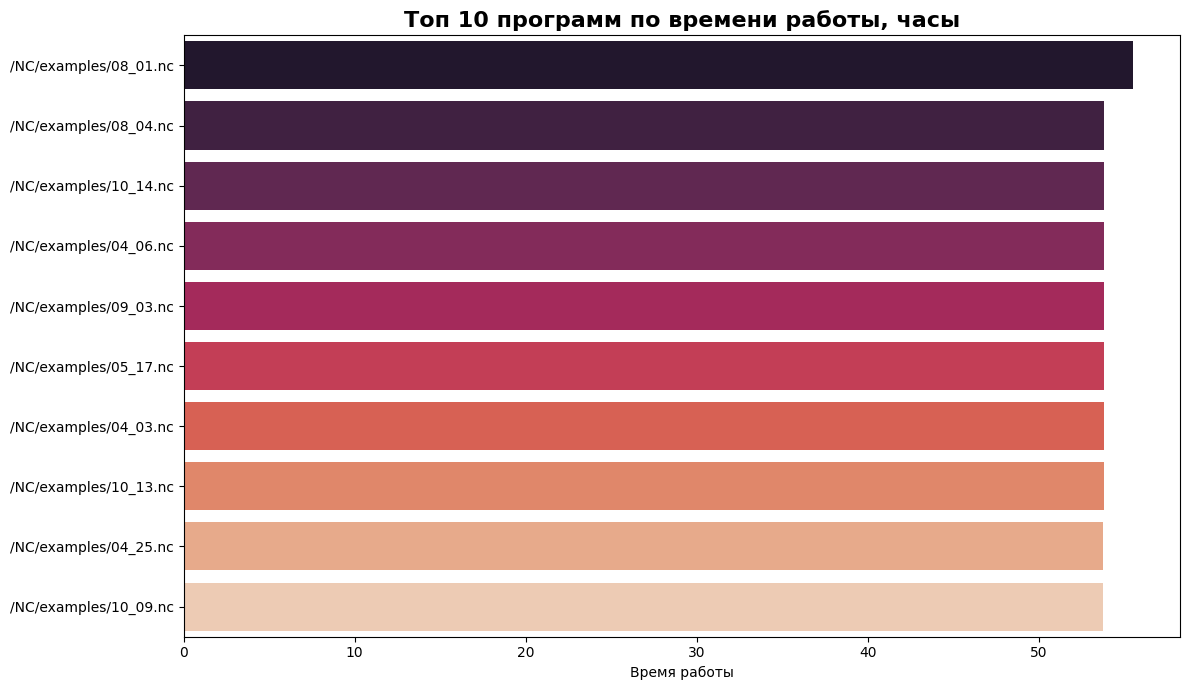

In [17]:
# Визуализация первых 10 программ
top_10_programs = program_time_df.sort_values(by='total_time_hours', ascending=False).head(10)

plt.figure(figsize=(12, 7))

sns.barplot(data=top_10_programs, x='total_time_hours', y='program_name', palette='rocket')

plt.title('Топ 10 программ по времени работы, часы', fontsize=16, fontweight='bold')
plt.xlabel('Время работы')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [18]:
# Стенд гравировального станка
df_cnc5.head()

,id,core_uptime_current,channel_uptime_total,program_completion_percent,program_name,channel_status,channel_mode,error_message,source,created_at,uptime_diff
0,1,256.76,317.80,48,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T22:33:34.000Z""",0.00
3,4,256.93,317.97,60,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T22:43:34.000Z""",0.17
5,6,257.09,318.13,70,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T22:53:34.000Z""",0.16
7,8,257.26,318.30,81,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T23:03:34.000Z""",0.17
9,10,257.43,318.47,91,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T23:13:34.000Z""",0.17


In [19]:
df_cnc5.groupby('program_name', as_index=False)['uptime_diff'].sum()

,program_name,uptime_diff
0,/NC/125test_3D_safe.nc,58.41


#### Внутри стенда гравировального станка работала только 1 программа

## Посчитайте какой режим канала ЧПУ работал дольше по времени?

In [20]:
df_real_cnc.head()

,id,core_uptime_current,channel_uptime_total,program_completion_percent,program_name,channel_status,channel_mode,error_message,source,created_at,uptime_diff
1,2,128.07,253.91,83,/NC/examples/04_06.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:33:34.000Z""",0.00
2,3,128.24,254.02,0,NaN,Готов,Авто,NaN,get/3,"""2025-10-11T22:43:34.000Z""",0.00
4,5,128.41,254.11,92,/NC/examples/04_25.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:53:34.000Z""",0.20
6,7,128.57,254.21,78,/NC/examples/05_07.nc,Работа,Авто,NaN,get/3,"""2025-10-11T23:03:34.000Z""",0.10
8,9,128.74,254.30,80,/NC/examples/05_17.nc,Работа,Авто,NaN,get/3,"""2025-10-11T23:13:34.000Z""",0.09


#### В этой задаче решил посчитать время сразу по обоим станкам, так как стенд гравировального станка все время находился в работе

In [21]:
df_channel_mode = df_real_cnc.sort_values(['source', 'created_at'])
df_channel_mode['uptime_diff'] = df_channel_mode.groupby(['source', 'channel_mode'])['channel_uptime_total'].diff()
df_channel_mode['uptime_diff'] = df_channel_mode['uptime_diff'].fillna(0)
df_channel_mode = df_channel_mode[df_channel_mode['uptime_diff'] >= 0]


mode_time_hours = df_channel_mode.groupby('channel_mode')['uptime_diff'].sum().sort_values(ascending=False)

print("Суммарное время работы по режимам канала (часы):")
mode_time_hours

Суммарное время работы по режимам канала (часы):


channel_mode
Авто      88.37
Неакт.    28.41
Name: uptime_diff, dtype: float64

/var/folders/_q/y78js8613z37pq4ldhx06pc00000gn/T/ipykernel_4142/2190675839.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='channel_mode', y='hours', palette='viridis')


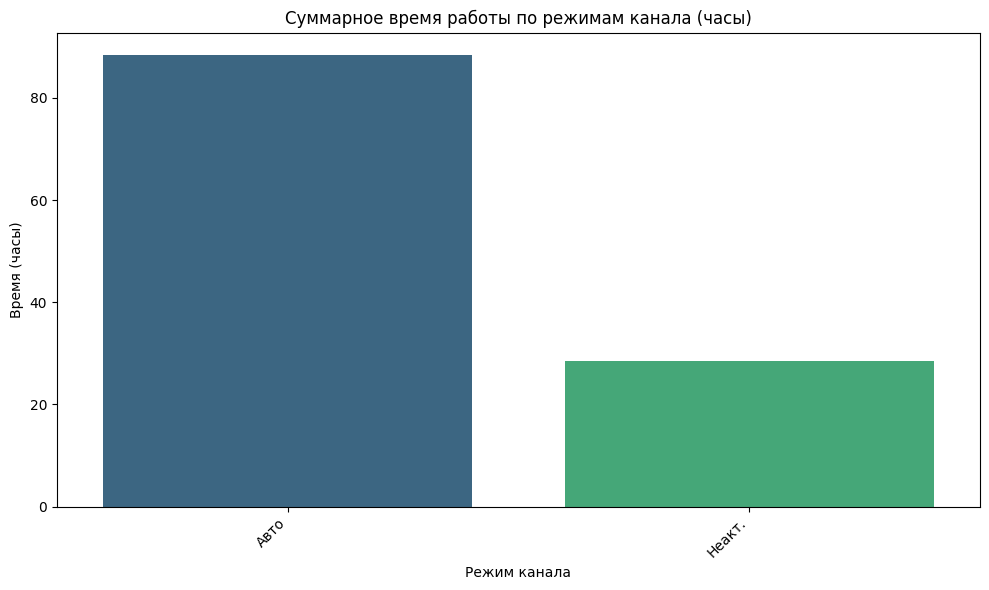

In [22]:
# Визуализация
plt.figure(figsize=(10, 6))


df_plot = mode_time_hours.reset_index()
df_plot.columns = ['channel_mode', 'hours']


sns.barplot(data=df_plot, x='channel_mode', y='hours', palette='viridis')

plt.title('Суммарное время работы по режимам канала (часы)')
plt.ylabel('Время (часы)')
plt.xlabel('Режим канала')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Как долго стенды ЧПУ были online и offline?

In [23]:
df_on_off = pd.read_csv('json_data.csv',sep=',')

In [24]:
df_on_off.head()

,id,core_uptime_current,channel_uptime_total,program_completion_percent,program_name,channel_status,channel_mode,error_message,source,created_at
0,1,256:45:32,317:48:05,48,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T22:33:34.000Z"""
1,2,128:04:21,253:54:54,83,/NC/examples/04_06.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:33:34.000Z"""
2,3,128:14:21,254:01:12,0,NaN,Готов,Авто,NaN,get/3,"""2025-10-11T22:43:34.000Z"""
3,4,256:55:32,317:58:04,60,/NC/125test_3D_safe.nc,Работа,Авто,NaN,get/5,"""2025-10-11T22:43:34.000Z"""
4,5,128:24:20,254:06:41,92,/NC/examples/04_25.nc,Работа,Авто,NaN,get/3,"""2025-10-11T22:53:34.000Z"""


In [25]:
df_on_off.created_at.min()

'"2025-10-11T22:33:34.000Z"'

#### Eсли время работы ядра не меняется дольше 2 мин, можно считать, что стенд оффлайн

In [26]:
df_on_off['created_at'] = pd.to_datetime(df_on_off['created_at'].str.replace('"', '').str.replace('Z', ''))
df_on_off['core_uptime_current'] = pd.to_timedelta(df_on_off['core_uptime_current'])


df_on_off = df_on_off.dropna(subset=['core_uptime_current'])

# Сортируем данные по источнику и времени
df_on_off = df_on_off.sort_values(['source', 'created_at'])

# Рассчитываем разницу во времени работы ядра
df_on_off['time_diff'] = df_on_off.groupby('source')['created_at'].diff().dt.total_seconds().fillna(0)
df_on_off['core_diff'] = df_on_off.groupby('source')['core_uptime_current'].diff().dt.total_seconds().fillna(1)

# Определяем статус работы стенда по условиям
df_on_off['status'] = 'online'
df_on_off.loc[(df_on_off['time_diff'] > 120) & (df_on_off['core_diff'] <= 0), 'status'] = 'offline'
df_on_off.loc[df_on_off['error_message'].notna(), 'status'] = 'error'

# Суммируем время по статусам для всей выборки
time_summary = df_on_off.groupby('status')['time_diff'].sum()

time_summary_min = time_summary / 60

print('Суммарное время по статусам (минуты):')
time_summary_min



Суммарное время по статусам (минуты):


status
error      432.05
online    6586.75
Name: time_diff, dtype: float64

## Определите ошибку, которая возникала чаще всего 

In [27]:
# Оставляемые записи, где возникали ошибка
df_errors = df_on_off.query('status == "error"')
df_errors = df_errors.drop(['time_diff','core_diff'],axis=1)
df_errors.head()

,id,core_uptime_current,channel_uptime_total,program_completion_percent,program_name,channel_status,channel_mode,error_message,source,created_at,status
40,41,5 days 11:24:21,255:37:14,25,/NC/examples/12_01.nc,Ошибка,Авто,Текущая кинематическая схема не поддерживает т...,get/3,2025-10-12 01:53:34,error
48,49,5 days 12:04:21,255:59:14,0,/NC/examples/ToZero.nc,Ошибка,Авто,Ошибка интерполяции (конфигурация осей).\n\nФа...,get/3,2025-10-12 02:33:34,error
56,57,5 days 12:44:21,256:18:00,0,/NC/examples/ToZero.nc,Ошибка,Авто,Ошибка интерполяции (конфигурация осей).\n\nФа...,get/3,2025-10-12 03:13:34,error
60,61,5 days 13:04:20,256:30:38,20,/NC/examples/11_04.nc,Ошибка,Авто,Текущая кинематическая схема не поддерживает т...,get/3,2025-10-12 03:33:34,error
72,73,5 days 14:04:21,257:00:18,0,/NC/examples/ToZero.nc,Ошибка,Авто,Ошибка интерполяции (конфигурация осей).\n\nФа...,get/3,2025-10-12 04:33:34,error


In [28]:
errors = df_errors.error_message.value_counts()
errors = errors.reset_index()
errors

,error_message,count
0,Ошибка интерполяции (конфигурация осей).\n\nФа...,28
1,Текущая кинематическая схема не поддерживает т...,2
2,Текущая кинематическая схема не поддерживает т...,1
3,Текущая кинематическая схема не поддерживает т...,1
4,Интерпретатор: вход в эквидистанту не является...,1
5,Текущая кинематическая схема не поддерживает т...,1
6,Текущая кинематическая схема не поддерживает т...,1
7,ПЛК запретил выполнять М6.\n\nКанал 1. ПЛК зап...,1


In [29]:
f'Самая частая ошибка: {errors.error_message[0]}'

'Самая частая ошибка: Ошибка интерполяции (конфигурация осей).\n\nФайл /NC/examples/ToZero.nc, строка 3: G90 G00 X0 Y0 Z0 B0 C0. Не все оси кадра сконфигурированы в кинематике. Выполняется аварийный останов канала.\n\nДействия: ChanRst, ChkKin, RstNcPrg'